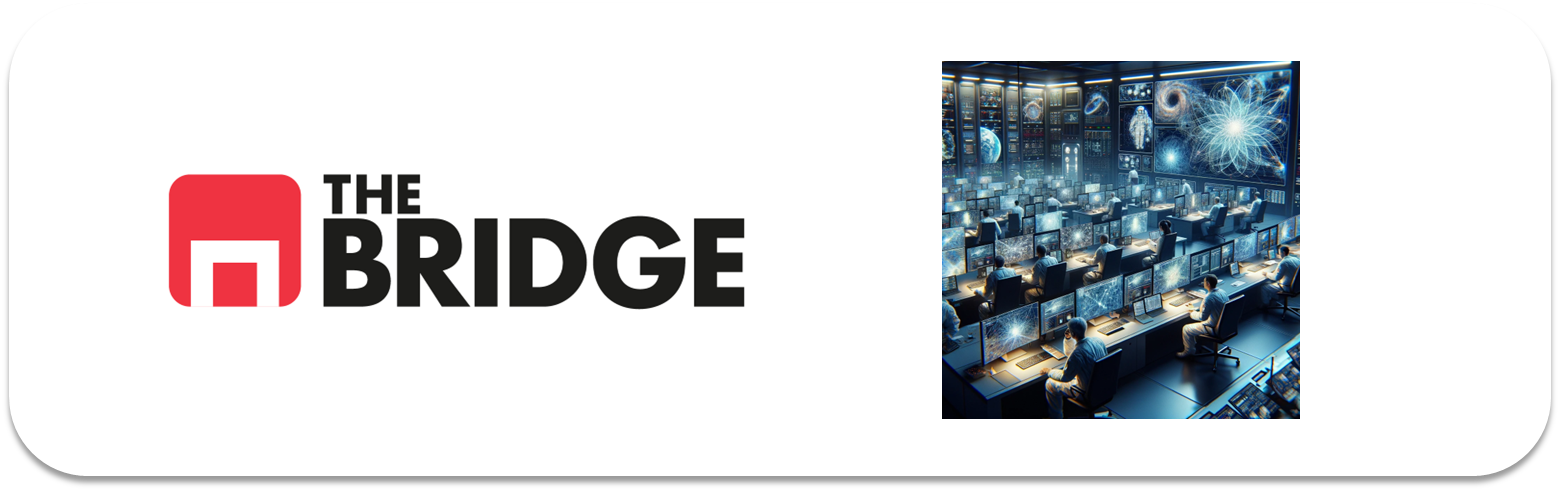

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



#### CARGAR IMAGENES

In [6]:
train_dirs = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_dir = "data/github_test"

def load_images(directories):
    X, y = [], []

    for directory in directories:
        for filename in os.listdir(directory):

            path = os.path.join(directory, filename)
            img = cv2.imread(path)

            if img is None:
                continue

            img = cv2.cvtColor(cv2.resize(img, (32,32)), cv2.COLOR_BGR2RGB)

            X.append(img)
            y.append(0 if filename.startswith("cat") else 1)

    return np.array(X), np.array(y)

X_train, y_train = load_images(train_dirs)
X_test, y_test = load_images([test_dir])

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4000, 32, 32, 3) (4000,)
(1000, 32, 32, 3) (1000,)


#### MINI EDA

Gatos: 2000
Perros: 2000


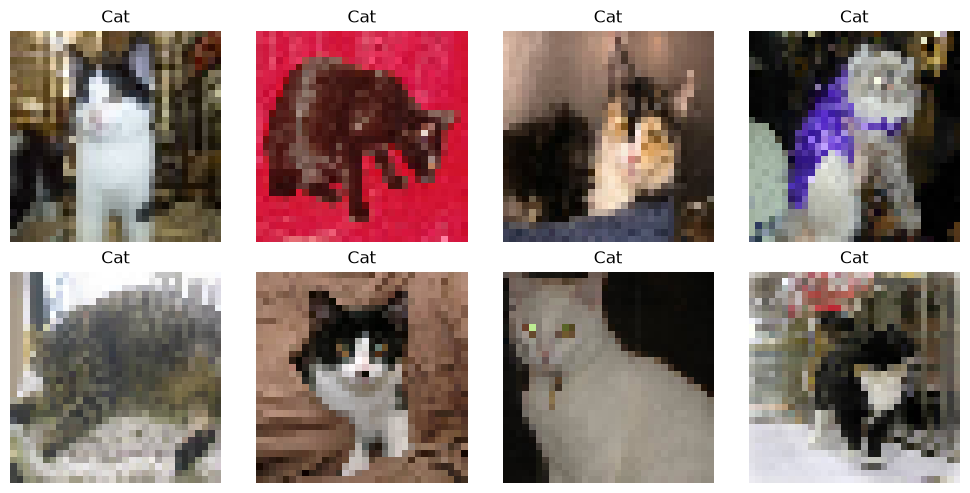

In [7]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Gatos:", np.sum(y_train==0))
print("Perros:", np.sum(y_train==1))

plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i])
    plt.title("Cat" if y_train[i]==0 else "Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### CONSTRUCCIÓN DEL MODELO


In [8]:
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

#### ENTRENAMIENTO

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5534 - loss: 0.6831 - val_accuracy: 0.5375 - val_loss: 0.6874
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5959 - loss: 0.6657 - val_accuracy: 0.5100 - val_loss: 0.7214
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6234 - loss: 0.6469 - val_accuracy: 0.5987 - val_loss: 0.6718
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6609 - loss: 0.6086 - val_accuracy: 0.6862 - val_loss: 0.6021
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6859 - loss: 0.5869 - val_accuracy: 0.6875 - val_loss: 0.5982
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6963 - loss: 0.5643 - val_accuracy: 0.6888 - val_loss: 0.5961
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7384 - loss: 0.5181 - val_accuracy: 0.6888 - val_loss: 0.5815
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7581 - loss: 0.5018 - val_accu

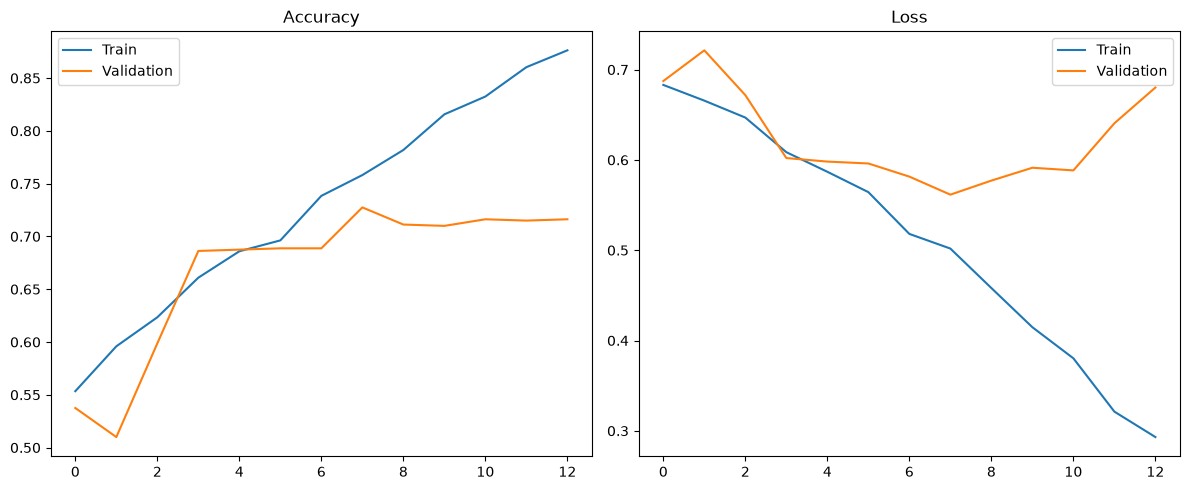

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val,y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

#### EVALUACIÓN

Accuracy: 0.6900
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

         Cat       0.71      0.64      0.67       500
         Dog       0.67      0.74      0.70       500

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.69      0.69      0.69      1000



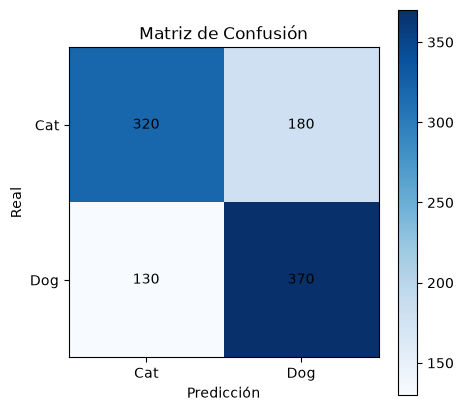

In [10]:
loss, accuracy = model.evaluate(X_test,y_test,verbose=0)

print(f"Accuracy: {accuracy:.4f}")

y_prob = model.predict(X_test).flatten()
y_pred = (y_prob>=0.5).astype(int)

print(classification_report(y_test,y_pred,target_names=["Cat","Dog"]))

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm,cmap="Blues")

plt.xticks([0,1],["Cat","Dog"])
plt.yticks([0,1],["Cat","Dog"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.colorbar()
plt.show()

#### Seleccionar el 10% de imágenes más difíciles

In [11]:
errores = np.where(y_pred != y_test)[0]

cat_mal = errores[y_test[errores]==0]
dog_mal = errores[y_test[errores]==1]

cat_conf = y_prob[cat_mal]
dog_conf = 1-y_prob[dog_mal]

n_cat = max(1,int(len(cat_mal)*0.10))
n_dog = max(1,int(len(dog_mal)*0.10))

cat_top = cat_mal[np.argsort(cat_conf)[-n_cat:]]
dog_top = dog_mal[np.argsort(dog_conf)[-n_dog:]]

seleccion = np.concatenate([cat_top,dog_top])

print("Imágenes seleccionadas:", len(seleccion))

Imágenes seleccionadas: 31


#### Mostrar las imágenes seleccionadas

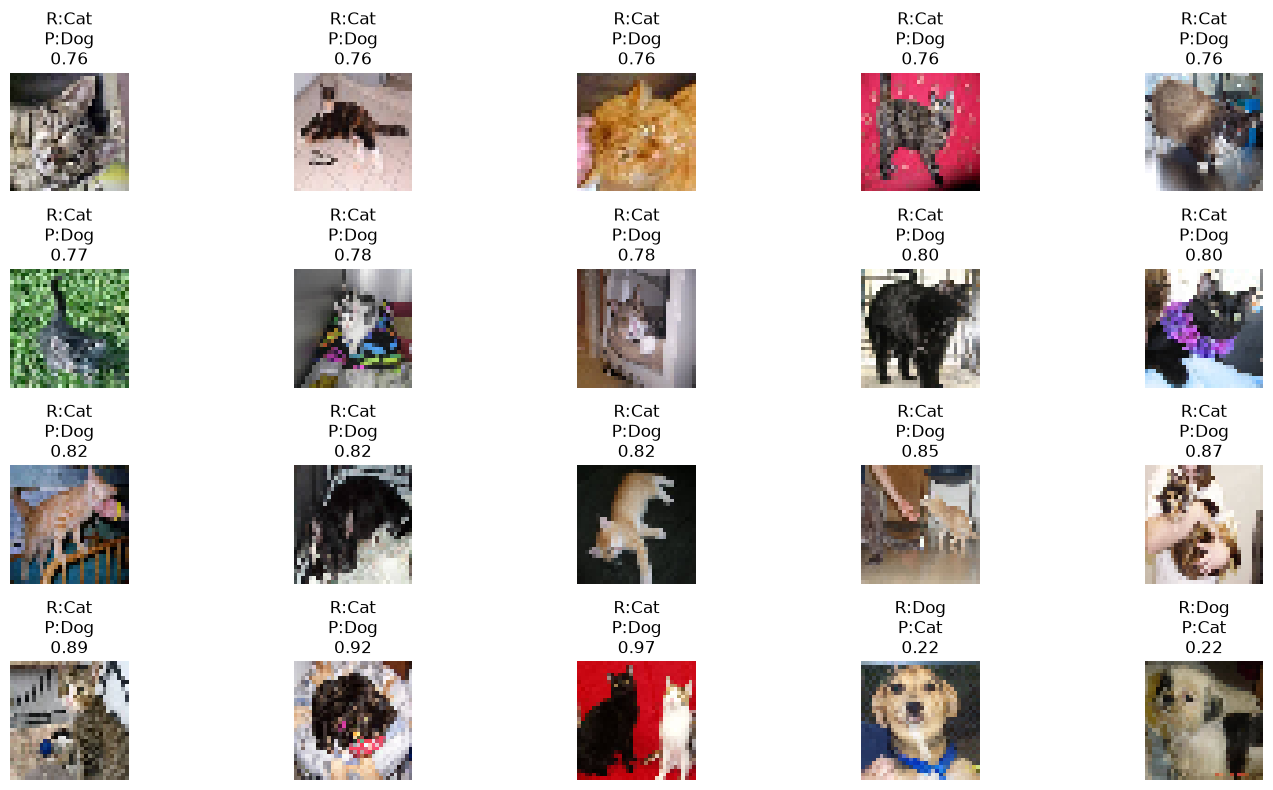

In [12]:
plt.figure(figsize=(15,8))

for i,idx in enumerate(seleccion[:20]):
    plt.subplot(4,5,i+1)

    plt.imshow(X_test[idx])

    real = "Cat" if y_test[idx]==0 else "Dog"
    pred = "Cat" if y_pred[idx]==0 else "Dog"

    plt.title(f"R:{real}\nP:{pred}\n{y_prob[idx]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()